In [25]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from data_loader import PairData

torch.manual_seed(42)
np.random.seed(42)

In [26]:
# ── Data & cointegration ─────────────────────────────────────────────────
data   = PairData('../../data/real_pair_MCD_YUM.csv')
prices = data.s
N      = prices.shape[1]
train_end = 3 * N // 4

log_A = np.log(prices[0])
log_B = np.log(prices[1])

X_ols = np.column_stack([np.ones(train_end), log_B[:train_end]])
coef, _, _, _ = np.linalg.lstsq(X_ols, log_A[:train_end], rcond=None)
intercept, beta = float(coef[0]), float(coef[1])

spread     = log_A - beta * log_B - intercept
train_mean = spread[:train_end].mean()
train_std  = spread[:train_end].std()
z          = (spread - train_mean) / train_std

print(f'N={N}  train_end={train_end}  test_end={N}')
print(f'beta={beta:.4f}  intercept={intercept:.4f}')
print(f'Note: no volume data in CSV — price-only features')

N=5032  train_end=3774  test_end=5032
beta=0.9830  intercept=0.6916
Note: no volume data in CSV — price-only features


In [27]:
# ── Feature engineering ──────────────────────────────────────────────────
s = pd.Series(spread)
z_s = pd.Series(z)

# MACD on spread (12, 26, 9)
ema12     = s.ewm(span=12, adjust=False).mean()
ema26     = s.ewm(span=26, adjust=False).mean()
macd_line = ema12 - ema26
signal    = macd_line.ewm(span=9, adjust=False).mean()
macd_hist = macd_line - signal

# Feedforward features
momentum  = z_s.diff(5)             # 5-day z-score change
roll_mean = z_s.rolling(20).mean()  # 20-day rolling mean
roll_std  = z_s.rolling(20).std()   # 20-day rolling std

# CNN features: z-score differences (avoids division by near-zero spread)
# z_diff[t] = z[t] - z[t-1]  — equivalent to normalised spread changes
z_diff = z_s.diff()

# ── Build raw feature arrays (length N) ─────────────────────────────────
SEQ_LEN = 20   # CNN lookback

X_ff_raw = np.column_stack([
    z_s.values,
    momentum.values,
    macd_line.values,
    macd_hist.values,
    roll_mean.values,
    roll_std.values,
])  # (N, 6)

# CNN windows: X_cnn[t] = z_diff[t-SEQ_LEN+1 : t+1]
X_cnn_raw = np.full((N, SEQ_LEN), np.nan)
for t in range(SEQ_LEN - 1, N):
    X_cnn_raw[t] = z_diff.values[t - SEQ_LEN + 1 : t + 1]

# Target: next-day z-score
y_raw = np.full(N, np.nan)
y_raw[:-1] = z_s.values[1:]

# ── Valid index set ──────────────────────────────────────────────────────
valid_mask = (
    ~np.any(np.isnan(X_ff_raw),  axis=1) &
    ~np.any(np.isnan(X_cnn_raw), axis=1) &
    ~np.isnan(y_raw)
)
valid_idx = np.where(valid_mask)[0]

print(f'Valid indices: {valid_idx[0]} → {valid_idx[-1]}  ({len(valid_idx)} rows)')
print(f'FF features:  [z, momentum, macd_line, macd_hist, roll_mean_20, roll_std_20]')
print(f'CNN input:    {SEQ_LEN}-step z-score differences')

Valid indices: 20 → 5030  (5011 rows)
FF features:  [z, momentum, macd_line, macd_hist, roll_mean_20, roll_std_20]
CNN input:    20-step z-score differences


In [28]:
# ── Training index set (full train, no walk-forward) ─────────────────────
train_idx = valid_idx[valid_idx < train_end]
print(f'Training samples: {len(train_idx)}  t∈[{train_idx[0]}, {train_idx[-1]}]')

Training samples: 3754  t∈[20, 3773]


In [29]:
# ── Model definitions ────────────────────────────────────────────────────

class GaussianFF(nn.Module):
    """Feedforward network → (μ, log_var)"""
    def __init__(self, in_dim=6, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.mu_head = nn.Linear(hidden, 1)
        self.lv_head = nn.Linear(hidden, 1)

    def forward(self, x):
        h = self.net(x)
        return self.mu_head(h).squeeze(-1), self.lv_head(h).squeeze(-1)


class GaussianCNN(nn.Module):
    """1D CNN on SEQ_LEN z-diff steps → (μ, log_var)"""
    def __init__(self, seq_len=20, hidden=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),   # → (batch, 32, 1)
        )
        self.fc      = nn.Linear(32, hidden)
        self.mu_head = nn.Linear(hidden, 1)
        self.lv_head = nn.Linear(hidden, 1)

    def forward(self, x):
        # x: (batch, seq_len)
        h = self.conv(x.unsqueeze(1)).squeeze(-1)   # (batch, 32)
        h = F.relu(self.fc(h))
        return self.mu_head(h).squeeze(-1), self.lv_head(h).squeeze(-1)


class GaussianHybrid(nn.Module):
    """CNN on z-diffs + current z_score → (μ, log_var)"""
    def __init__(self, seq_len=20, hidden=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.fc      = nn.Linear(32 + 1, hidden)   # +1 for z_score
        self.mu_head = nn.Linear(hidden, 1)
        self.lv_head = nn.Linear(hidden, 1)

    def forward(self, x_seq, z_now):
        # x_seq: (batch, seq_len),  z_now: (batch,)
        h = self.conv(x_seq.unsqueeze(1)).squeeze(-1)         # (batch, 32)
        h = torch.cat([h, z_now.unsqueeze(-1)], dim=-1)       # (batch, 33)
        h = F.relu(self.fc(h))
        return self.mu_head(h).squeeze(-1), self.lv_head(h).squeeze(-1)


print('Models: GaussianFF | GaussianCNN | GaussianHybrid')

Models: GaussianFF | GaussianCNN | GaussianHybrid


In [30]:
# ── Training utilities ───────────────────────────────────────────────────

def gaussian_nll(mu, log_var, y):
    """loss = log(σ²) + (y - μ)² / σ²"""
    return (log_var + (y - mu)**2 / log_var.exp()).mean()


def normalise(X_tr, X_te=None):
    mu  = X_tr.mean(0, keepdim=True)
    std = X_tr.std(0, keepdim=True).clamp(min=1e-8)
    if X_te is None:
        return (X_tr - mu) / std
    return (X_tr - mu) / std, (X_te - mu) / std


def run_fold(model, optimizer, X_tr, y_tr, X_te, y_te,
             n_epochs, batch_size, extra_tr=None, extra_te=None):
    """Train one fold, return (mu_pred, var_pred, y_true) on test set."""
    if extra_tr is None:
        dataset = TensorDataset(X_tr, y_tr)
    else:
        dataset = TensorDataset(X_tr, extra_tr, y_tr)

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    model.train()
    for _ in range(n_epochs):
        for batch in loader:
            optimizer.zero_grad()
            if extra_tr is None:
                xb, yb = batch
                mu, lv = model(xb)
            else:
                xb, xb2, yb = batch
                mu, lv = model(xb, xb2)
            gaussian_nll(mu, lv, yb).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

    model.eval()
    with torch.no_grad():
        if extra_te is None:
            mu_p, lv_p = model(X_te)
        else:
            mu_p, lv_p = model(X_te, extra_te)
    return mu_p.numpy(), np.exp(lv_p.numpy()), y_te.numpy()


def run_walk_forward(model_fn, n_epochs=100, batch_size=128, lr=3e-4, label=''):
    """
    model_fn() returns a fresh (model, is_hybrid) tuple.
    Returns (mu_all, var_all, y_all) concatenated across all folds.
    """
    all_mu, all_var, all_y = [], [], []

    for fi, (tr_abs, te_abs) in enumerate(folds):
        model, is_hybrid = model_fn()
        opt = torch.optim.Adam(model.parameters(), lr=lr)

        # FF features
        X_ff_tr = torch.tensor(X_ff_raw[tr_abs].astype(np.float32))
        X_ff_te = torch.tensor(X_ff_raw[te_abs].astype(np.float32))
        X_ff_tr, X_ff_te = normalise(X_ff_tr, X_ff_te)

        # CNN features
        X_cnn_tr = torch.tensor(X_cnn_raw[tr_abs].astype(np.float32))
        X_cnn_te = torch.tensor(X_cnn_raw[te_abs].astype(np.float32))
        X_cnn_tr, X_cnn_te = normalise(X_cnn_tr, X_cnn_te)

        y_tr = torch.tensor(y_raw[tr_abs].astype(np.float32))
        y_te = torch.tensor(y_raw[te_abs].astype(np.float32))

        if isinstance(model, GaussianFF):
            mu_p, var_p, y_p = run_fold(model, opt, X_ff_tr, y_tr, X_ff_te, y_te,
                                        n_epochs, batch_size)
        elif isinstance(model, GaussianCNN):
            mu_p, var_p, y_p = run_fold(model, opt, X_cnn_tr, y_tr, X_cnn_te, y_te,
                                        n_epochs, batch_size)
        else:  # Hybrid
            z_now_tr = X_ff_tr[:, 0]   # z_score (fold-normalised)
            z_now_te = X_ff_te[:, 0]
            mu_p, var_p, y_p = run_fold(model, opt, X_cnn_tr, y_tr, X_cnn_te, y_te,
                                        n_epochs, batch_size,
                                        extra_tr=z_now_tr, extra_te=z_now_te)

        all_mu.append(mu_p); all_var.append(var_p); all_y.append(y_p)
        print(f'  {label} fold {fi+1}/{len(folds)}', end='\r')

    print(f'  {label} done        ')
    return np.concatenate(all_mu), np.concatenate(all_var), np.concatenate(all_y)


print('Training utilities ready.')

Training utilities ready.


In [31]:
# ── Train Hybrid on full training set ────────────────────────────────────
N_EPOCHS   = 150
BATCH_SIZE = 128
LR         = 3e-4

model = GaussianHybrid(seq_len=SEQ_LEN, hidden=64)
opt   = torch.optim.Adam(model.parameters(), lr=LR)

X_ff_t  = torch.tensor(X_ff_raw[train_idx].astype(np.float32))
X_cnn_t = torch.tensor(X_cnn_raw[train_idx].astype(np.float32))
y_t     = torch.tensor(y_raw[train_idx].astype(np.float32))

ff_mean  = X_ff_t.mean(0, keepdim=True);  ff_std  = X_ff_t.std(0, keepdim=True).clamp(min=1e-8)
cnn_mean = X_cnn_t.mean(0, keepdim=True); cnn_std = X_cnn_t.std(0, keepdim=True).clamp(min=1e-8)

X_ff_n  = (X_ff_t  - ff_mean)  / ff_std
X_cnn_n = (X_cnn_t - cnn_mean) / cnn_std
z_now   = X_ff_n[:, 0]

dataset = TensorDataset(X_cnn_n, z_now, y_t)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

model.train()
for ep in range(N_EPOCHS):
    ep_loss = 0.0
    for xb_cnn, xb_z, yb in loader:
        opt.zero_grad()
        mu_b, lv_b = model(xb_cnn, xb_z)
        loss = gaussian_nll(mu_b, lv_b, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        ep_loss += loss.item()
    if (ep + 1) % 30 == 0:
        print(f'ep {ep+1:3d}/{N_EPOCHS}  loss={ep_loss/len(loader):.4f}')

model.eval()

# Store predictions on training set for downstream visualisation cells
with torch.no_grad():
    mu_tr, lv_tr = model(X_cnn_n, z_now)
results = {'Hybrid': (mu_tr.numpy(), np.exp(lv_tr.numpy()), y_t.numpy())}
z_arr   = z_s.values   # used by signal viz cell

print('Training done.')

ep  30/150  loss=-3.1986
ep  60/150  loss=-3.2339
ep  90/150  loss=-3.2442
ep 120/150  loss=-3.2441
ep 150/150  loss=-3.2538
Training done.


In [32]:
# ── Save model + normalisation params ────────────────────────────────────
import os
os.makedirs('../models', exist_ok=True)
HYBRID_PATH = '../models/hybrid_spread_predictor.pt'

torch.save({
    'model_state': model.state_dict(),
    'ff_mean':  ff_mean.numpy(),
    'ff_std':   ff_std.numpy(),
    'cnn_mean': cnn_mean.numpy(),
    'cnn_std':  cnn_std.numpy(),
    'seq_len':  SEQ_LEN,
    'hidden':   64,
}, HYBRID_PATH)
print(f'Saved → {HYBRID_PATH}')

Saved → ../models/hybrid_spread_predictor.pt


In [33]:
# ── Metrics ──────────────────────────────────────────────────────────────

def compute_metrics(mu, var, y, label=''):
    nll  = float(np.mean(np.log(var) + (y - mu)**2 / var))
    mse  = float(np.mean((y - mu)**2))
    r, _ = pearsonr(mu, y)
    sigma   = np.sqrt(var)
    covered = float(np.mean(np.abs(y - mu) <= sigma))
    print(f'{label:8s}  NLL={nll:+6.3f}  MSE={mse:.4f}  r={r:+.3f}  '
          f'sigma={sigma.mean():.3f}  ±1σ coverage={covered*100:.1f}% (ideal 68.3%)')
    return dict(nll=nll, mse=mse, r=r, sigma=sigma.mean(), coverage=covered)

print('=== Training-set summary ===')
metrics = {}
for name, (mu, var, y) in results.items():
    metrics[name] = compute_metrics(mu, var, y, label=name)

mu0, var0 = np.zeros_like(results['Hybrid'][2]), np.ones_like(results['Hybrid'][2])
print()
compute_metrics(mu0, var0, results['Hybrid'][2], label='Naive')

=== Training-set summary ===
Hybrid    NLL=-3.287  MSE=0.0154  r=+0.992  sigma=0.118  ±1σ coverage=77.1% (ideal 68.3%)

Naive     NLL=+0.981  MSE=0.9815  r=+nan  sigma=1.000  ±1σ coverage=71.2% (ideal 68.3%)


/tmp/ipykernel_363272/2999902440.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(mu, y)


{'nll': 0.9814760684967041,
 'mse': 0.9814760684967041,
 'r': np.float32(nan),
 'sigma': np.float32(1.0),
 'coverage': 0.7115077250932339}

KeyError: 'FF'

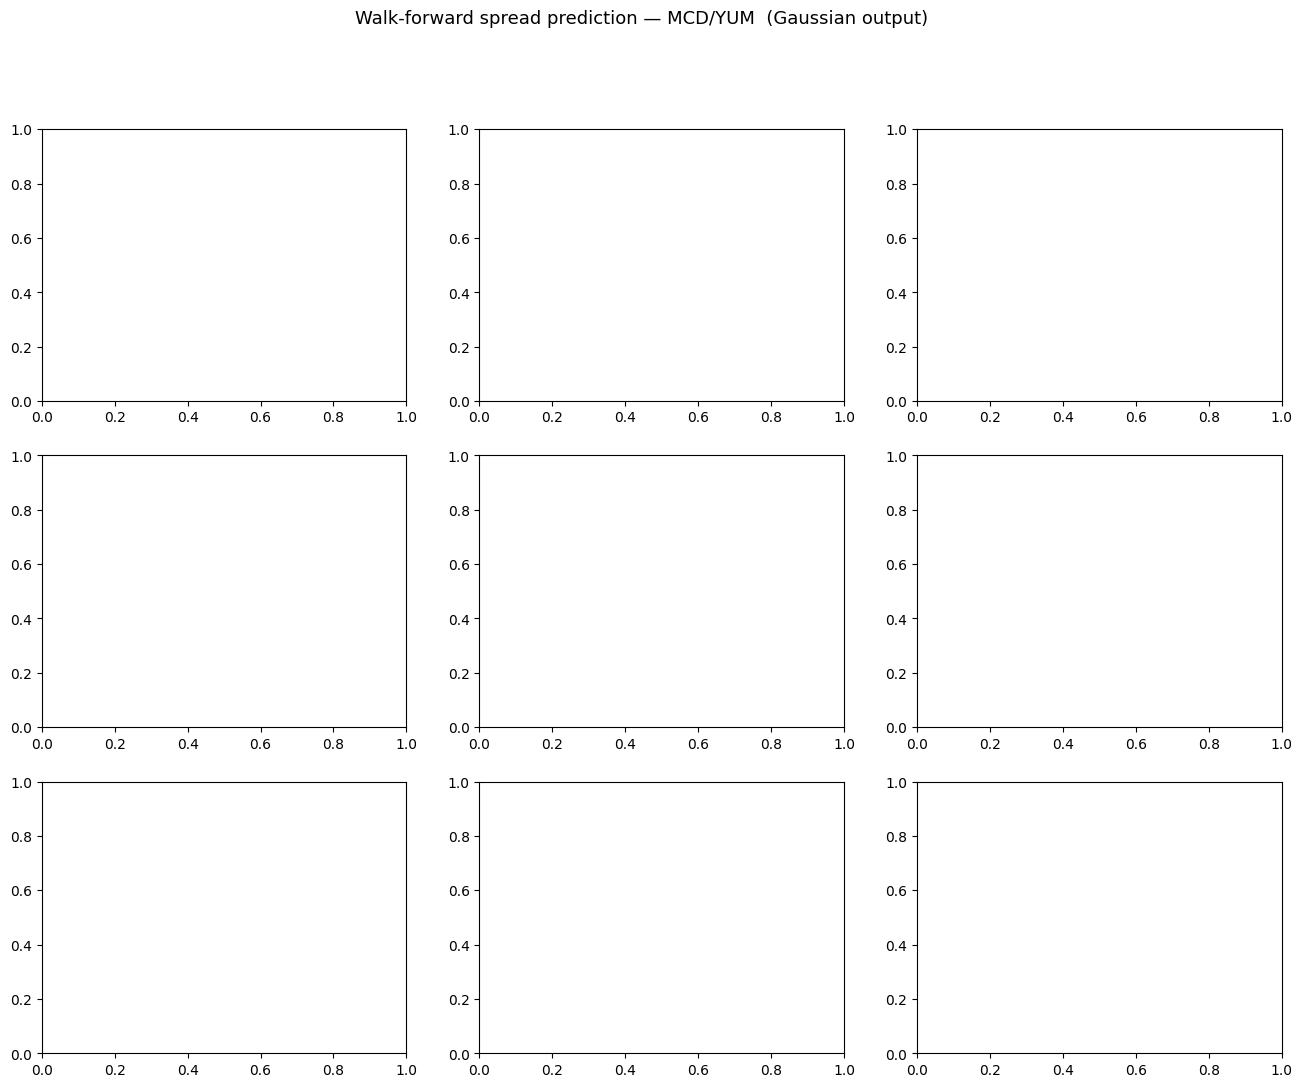

In [34]:
# ── Visualisation ────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Walk-forward spread prediction — MCD/YUM  (Gaussian output)', fontsize=13)

for col, name in enumerate(['FF', 'CNN', 'Hybrid']):
    mu, var, y = results[name]
    sigma = np.sqrt(var)
    T = len(y)
    t = np.arange(T)

    # Row 0: predicted mean vs actual
    ax = axes[0, col]
    ax.plot(t, y,      lw=0.7, color='black', alpha=0.7, label='actual z')
    ax.plot(t, mu,     lw=0.8, color='royalblue', label='predicted μ')
    ax.fill_between(t, mu - sigma, mu + sigma, alpha=0.2, color='royalblue')
    ax.set_title(f'{name}  r={metrics[name]["r"]:+.3f}')
    ax.set_xlabel('Walk-forward step')
    ax.set_ylabel('Z-score')
    ax.legend(fontsize=7)
    ax.axhline(0, color='gray', lw=0.5, ls='--')

    # Row 1: scatter predicted vs actual
    ax = axes[1, col]
    lim = max(np.abs(y).max(), np.abs(mu).max()) * 1.05
    ax.scatter(y, mu, s=2, alpha=0.3, color='steelblue')
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1)
    ax.set_xlabel('Actual z(t+1)')
    ax.set_ylabel('Predicted μ')
    ax.set_title(f'{name}  MSE={metrics[name]["mse"]:.4f}')
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)

    # Row 2: predicted σ over time (uncertainty)
    ax = axes[2, col]
    ax.plot(t, sigma, lw=0.7, color='darkorange')
    ax.axhline(1.0,  color='gray', lw=0.8, ls='--', label='σ=1 (prior)')
    ax.axhline(sigma.mean(), color='red', lw=0.8, ls=':', label=f'mean={sigma.mean():.3f}')
    ax.set_xlabel('Walk-forward step')
    ax.set_ylabel('Predicted σ')
    ax.set_title(f'{name}  coverage={metrics[name]["coverage"]*100:.1f}%')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

In [ ]:
# ── Calibration check ────────────────────────────────────────────────────
from scipy.stats import norm as scipy_norm

k_vals    = np.linspace(0.1, 3.0, 30)
ideal_cov = scipy_norm.cdf(k_vals) - scipy_norm.cdf(-k_vals)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_vals, ideal_cov, 'k--', lw=1.5, label='Ideal Gaussian')

mu, var, y = results['Hybrid']
sigma      = np.sqrt(var)
emp_cov    = [np.mean(np.abs(y - mu) <= k * sigma) for k in k_vals]
ax.plot(k_vals, emp_cov, color='green', lw=1.5, label='Hybrid')

ax.set_xlabel('k  (coverage at ±k·σ)')
ax.set_ylabel('Empirical coverage')
ax.set_title('Calibration: empirical vs ideal Gaussian coverage')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── NLL / r bar charts ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

names = list(metrics.keys())
axes[0].bar(names, [metrics[n]['nll'] for n in names], color='green')
naive_nll = float(np.mean(np.log(np.ones_like(results['Hybrid'][2])) + results['Hybrid'][2]**2))
axes[0].axhline(naive_nll, color='red', ls='--', lw=1, label='Naive NLL')
axes[0].set_ylabel('NLL (lower = better)')
axes[0].set_title('Negative Log-Likelihood')
axes[0].legend(fontsize=8)

axes[1].bar(names, [metrics[n]['r'] for n in names], color='green')
axes[1].axhline(0, color='gray', lw=0.8, ls='--')
axes[1].set_ylabel('Pearson r')
axes[1].set_title('Predicted mean vs actual')

plt.tight_layout()
plt.show()

In [ ]:
# ── Directional accuracy ─────────────────────────────────────────────────
mu, var, y = results['Hybrid']
sigma      = np.sqrt(var)
z_prev     = z_arr[train_idx]   # current z at each training index

pred_change   = mu - z_prev
actual_change = y  - z_prev
nonzero       = actual_change != 0
pred_dir      = np.sign(pred_change[nonzero])
actual_dir    = np.sign(actual_change[nonzero])
snr           = np.abs(pred_change[nonzero]) / (sigma[nonzero] + 1e-8)

print('=== Directional accuracy (training set) ===')
print(f'Unconditional: {np.mean(pred_dir == actual_dir)*100:.1f}%  (n={nonzero.sum()}, baseline=50%)')
for k in [0.1, 0.2, 0.5]:
    mask = snr >= k
    if mask.sum() < 10: break
    acc = np.mean(pred_dir[mask] == actual_dir[mask]) * 100
    print(f'  |signal/σ| >= {k:.1f}  acc={acc:.1f}%  n={mask.sum()}  ({mask.mean()*100:.0f}% of days)')

fig, ax = plt.subplots(figsize=(7, 4))
pred_chg   = mu - z_prev
actual_chg = y  - z_prev
lim = max(np.abs(actual_chg).max(), np.abs(pred_chg).max()) * 1.05
ax.scatter(actual_chg, pred_chg, s=2, alpha=0.2, color='steelblue')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.plot([-lim, lim], [-lim, lim], 'r--', lw=0.8)
acc_all = np.mean(np.sign(pred_chg[actual_chg != 0]) == np.sign(actual_chg[actual_chg != 0])) * 100
ax.set_title(f'Hybrid  dir acc={acc_all:.1f}%')
ax.set_xlabel('Actual change'); ax.set_ylabel('Predicted change')
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
plt.tight_layout()
plt.show()

In [ ]:
# ── Signal visualisation — Hybrid model, spread with confident buy/sell markers
# Green ▲  : model predicts spread will rise  (buy the spread)
# Red   ▼  : model predicts spread will fall  (sell the spread)
# Only shown when σ < SIGMA_PCT-th percentile  (most confident predictions)

SIGMA_PCT = 30   # adjust: lower = fewer but more confident signals

mu, var, y = results['Hybrid']
sigma  = np.sqrt(var)
z_prev = z_arr[train_idx]

pred_dir = np.sign(mu - z_prev)
thresh   = np.percentile(sigma, SIGMA_PCT)
conf     = sigma < thresh

buy_idx  = train_idx[(pred_dir > 0) & conf]
sell_idx = train_idx[(pred_dir < 0) & conf]

t_lo, t_hi = int(train_idx[0]), int(train_idx[-1]) + 1
t_plot = np.arange(t_lo, t_hi)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(t_plot, spread[t_plot], color='black', lw=0.6, alpha=0.7, label='spread')
ax.axhline(float(spread[:train_end].mean()), color='gray', lw=0.6, ls='--')
ax.scatter(buy_idx,  spread[buy_idx],  color='green', marker='^', s=40, zorder=5,
           label=f'buy  (n={len(buy_idx)})')
ax.scatter(sell_idx, spread[sell_idx], color='red',   marker='v', s=40, zorder=5,
           label=f'sell (n={len(sell_idx)})')

ax.set_ylabel('Spread')
ax.set_xlabel('Time index')
ax.set_title(
    f'Hybrid  |  sigma threshold={thresh:.4f} (bottom {SIGMA_PCT}%)  |  '
    f'signals on {len(buy_idx)+len(sell_idx)}/{len(train_idx)} days  '
    f'({(len(buy_idx)+len(sell_idx))/len(train_idx)*100:.0f}%)'
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()